# Taller: Auditoría de Desempeño para Negocios Digitales:

## ESCUELA POLITÉCNICA NACIONAL

## Facultad de Ingeniería de Sistemas

#### Ingeniería en Ciencia de Datos e Inteligencia Artificial

##### Segundo Semestre

---

**Estudiante:** Edwin Daniel Paredes

**Fecha:** 19 de junio de 2026



## Parte 1: Análisis de datos sintéticos

En esta parte vamos a analizar un dataset de transacciones y determinar si la estrategia de M-Commerce (App Móvil) es más rentable que el E-Commerce tradicional (Web Desktop).

Vamos a generar una base de datos aleatoria, que simula la salida de un TPS.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generar datos simulados
np.random.seed(42)
data = {
    'ID_Transaccion': range(1001, 1051),
    'Canal': np.random.choice(['Web Desktop', 'App Móvil'], 50, p=[0.4, 0.6]),
    'Metodo_Pago': np.random.choice(['Tarjeta Crédito', 'PayPal', 'Transferencia'], 50),
    'Total_Venta': np.random.randint(20, 500, 50),
    'Categoria': np.random.choice(['Electrónica', 'Moda', 'Hogar'], 50)
}

df = pd.DataFrame(data)
df.head()

,ID_Transaccion,Canal,Metodo_Pago,Total_Venta,Categoria
0,1001,Web Desktop,Transferencia,235,Moda
1,1002,App Móvil,PayPal,312,Moda
2,1003,App Móvil,PayPal,118,Electrónica
3,1004,App Móvil,PayPal,191,Moda
4,1005,Web Desktop,PayPal,379,Electrónica


### ¿Qué preguntas deberíamos plantearnos para obtener las respuestas que buscamos?

Buscamos saber cuál de las dos estrategias (M-Commerce o E-Commerce) es la más rentable.

Vamos a crear 4 KPIs para un MIS que nos permitan responder esta pregunta.

KPI 1 - Venta promedio por canal
Canal
App Móvil      260.73
Web Desktop    231.21
Name: Total_Venta, dtype: float64

KPI 2 - Participación del total vendido (%)
Canal
App Móvil      54.99
Web Desktop    45.01
Name: Total_Venta, dtype: float64

KPI 3 - Porcentaje de ventas altas por canal
Canal
App Móvil      26.92
Web Desktop    25.00
Name: Venta_Alta, dtype: float64

KPI 4 - Cantidad de categorías vendidas por canal
Canal
App Móvil      3
Web Desktop    3
Name: Categoria, dtype: int64


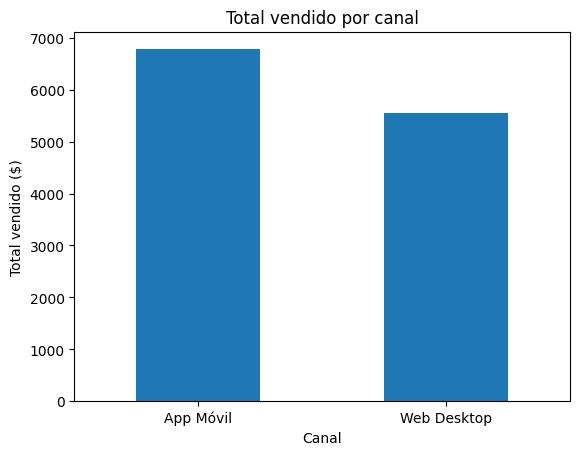

In [ ]:
# KPI 1: Venta promedio por canal
kpi_ticket_canal = df.groupby('Canal')['Total_Venta'].mean().round(2)
print('KPI 1 - Venta promedio por canal')
print(kpi_ticket_canal)

# KPI 2: Participación del dinero generado por canal
kpi_participacion = (df.groupby('Canal')['Total_Venta'].sum() / df['Total_Venta'].sum() * 100).round(2)
print('\nKPI 2 - Participación del total vendido (%)')
print(kpi_participacion)

# KPI 3: Concentración de ventas altas por canal
umbral_ventas_altas = df['Total_Venta'].quantile(0.75)
kpi_ventas_altas = df.assign(Venta_Alta=df['Total_Venta'] >= umbral_ventas_altas) \
                    .groupby('Canal')['Venta_Alta'].mean().mul(100).round(2)
print('\nKPI 3 - Porcentaje de ventas altas por canal')
print(kpi_ventas_altas)

# KPI 4: Variedad comercial por canal
kpi_variedad = df.groupby('Canal')['Categoria'].nunique()
print('\nKPI 4 - Cantidad de categorías vendidas por canal')
print(kpi_variedad)

# Gráfico para comparar el total vendido
ventas_canal = df.groupby('Canal')['Total_Venta'].sum()
ventas_canal.plot(kind='bar')
plt.title('Total vendido por canal')
plt.xlabel('Canal')
plt.ylabel('Total vendido ($)')
plt.xticks(rotation=0)
plt.show()

**Interpretación**

Estos KPIs comparan el canal por valor promedio, peso económico dentro del total, capacidad de generar ventas altas y variedad de categorías. Con esto se puede decidir si conviene fortalecer la App Móvil o la Web Desktop.

En un MIS, estos indicadores servirían para que el negocio revise en qué canal se mueve más dinero y dónde existen mejores oportunidades comerciales.

## Parte 2: KPIs para E-Commerce

Para esta parte vamos a utilizar los datos que se encuentran en el repositorio en `/data/ecommerce.zip`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:

import os

data = pd.read_csv('ecommerce.zip')
data.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


### 1. KPIs de Gestión de Logística y Operaciones (Shipment & Warehouse)

Permiten medir la eficiencia en la distribución de los productos electrónicos.

1.1. **Costo Promedio de Envío por Modo de Transporte:** Ayuda a evaluar qué canales (Barco, Avión, Carretera) representan un mayor impacto financiero en relación con el peso del producto.

1.2. **Volumen de Ocupación por Bloque de Bodega (Warehouse Block):** Porcentaje o cantidad total de productos/peso administrados en cada bloque (A, B, C, D, E) para entender la carga operativa de la infraestructura.

1.3. **Peso Promedio del Producto por Modo de Envío:** Para analizar si se está optimizando la logística (ej. si los productos más pesados se están enviando por barco o si se está gastando de más enviándolos por avión).

1.1 Costo promedio del producto por modo de envío
Mode_of_Shipment
Road      210.475568
Ship      210.343072
Flight    209.306697
Name: Cost_of_the_Product, dtype: float64

1.2 Volumen de ocupación por bloque de bodega
                 cantidad_productos  peso_total  porcentaje_productos
Warehouse_block                                                      
A                              1833     6627118             16.665151
B                              1833     6664240             16.665151
C                              1833     6674560             16.665151
D                              1834     6655305             16.674243
F                              3666    13349327             33.330303

1.3 Peso promedio del producto por modo de envío
Mode_of_Shipment
Road      3649.550568
Ship      3631.457518
Flight    3629.378165
Name: Weight_in_gms, dtype: float64


<Axes: title={'center': 'Costo promedio por modo de envío'}, xlabel='Modo de envío', ylabel='Costo promedio'>

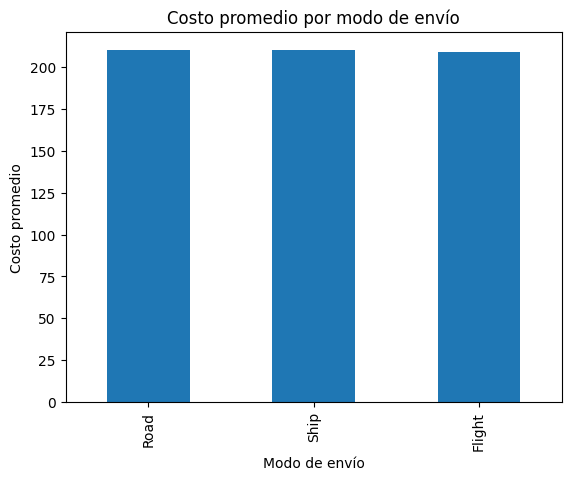

In [11]:
# 1. KPIs de Gestión de Logística y Operaciones

# 1.1 Costo promedio del producto por modo de envío
# El dataset no tiene una columna de costo de envío. Por eso uso Cost_of_the_Product
# como una aproximación para ver qué modo transporta productos más costosos.
kpi_1_1 = data.groupby('Mode_of_Shipment')['Cost_of_the_Product'].mean().sort_values(ascending=False)
print('1.1 Costo promedio del producto por modo de envío')
print(kpi_1_1)

# 1.2 Volumen de ocupación por bloque de bodega
# Se mide con cantidad de productos y peso total administrado por cada bloque.
kpi_1_2 = data.groupby('Warehouse_block').agg(
    cantidad_productos=('ID', 'count'),
    peso_total=('Weight_in_gms', 'sum')
)
kpi_1_2['porcentaje_productos'] = (kpi_1_2['cantidad_productos'] / len(data)) * 100
print('\n1.2 Volumen de ocupación por bloque de bodega')
print(kpi_1_2)

# 1.3 Peso promedio del producto por modo de envío
kpi_1_3 = data.groupby('Mode_of_Shipment')['Weight_in_gms'].mean().sort_values(ascending=False)
print('\n1.3 Peso promedio del producto por modo de envío')
print(kpi_1_3)

# Gráficos simples
kpi_1_1.plot(kind='bar', title='Costo promedio por modo de envío', xlabel='Modo de envío', ylabel='Costo promedio')

## Interpretación de los KPIs de Logística y Operaciones

Estis KPIs permiten comparar cómo se mueven los productos según el modo de envío y el bloque de bodega. El costo promedio por modo de envío permite identificar que transporte maneja productos más costosos. El volumen por bloque muestra si la carga de trabajo está distribuida o si un bloque concentra más productos. El peso promedio por modo de envío revisa si los productos pesados se envían por medios más adecuados.

### 2. KPIs de Gestión Comercial y Financiera (Sales & Revenue)

Enfocados en el rendimiento del dinero, los descuentos y la estrategia de precios.

2.1. **Ingreso Total Bruto y Costo Promedio del Producto:** Suma y promedio de la variable `Cost of the product` para entender el ticket promedio de la tienda de electrónica.

2.2. **Porcentaje de Descuento Promedio Otorgado:** Evaluar el impacto de la estrategia de promociones (`Discount offered`) y si los descuentos altos realmente correlacionan con clientes de mayor prioridad o compras previas.

2.3. **Margen Teórico Relativo por Importancia del Producto:** Cruzar `Product importance` (Low, Medium, High) con el costo para ver si los productos catalogados como "alta importancia" son también los más costosos o los que reciben más descuentos.

2.1 Ingreso total bruto y costo promedio del producto
Ingreso total bruto: 2311955
Costo promedio del producto: 210.2

2.2 Porcentaje de descuento promedio otorgado
Descuento promedio: 13.37 %

Descuento promedio según compras previas
Prior_purchases
2     15.322816
3     14.981795
4     10.845476
5      9.267288
6     11.064171
7     17.529412
8     13.320312
10    13.595506
Name: Discount_offered, dtype: float64

2.3 Margen teórico relativo por importancia del producto
                    costo_promedio  ...  valor_teorico_relativo
Product_importance                  ...                        
high                    203.871308  ...              173.970183
low                     212.059845  ...              184.400788
medium                  209.382415  ...              181.151024

[3 rows x 4 columns]


<Axes: title={'center': 'Costo promedio y valor teórico relativo por importancia'}, xlabel='Importancia del producto', ylabel='Valor'>

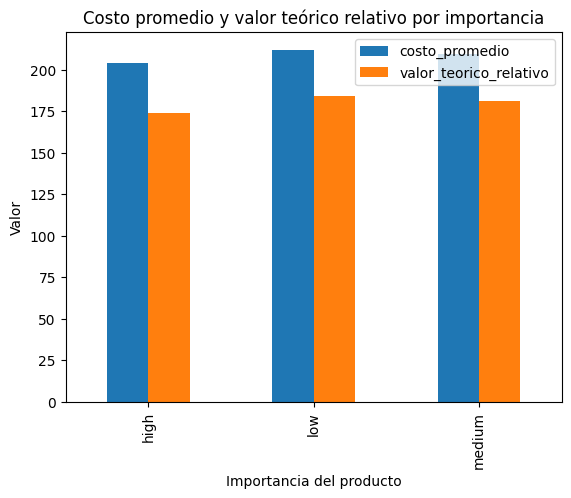

In [ ]:
# 2. KPIs de Gestión Comercial y Financiera

# 2.1 Ingreso total bruto y costo promedio del producto
ingreso_total_bruto = data['Cost_of_the_Product'].sum()
costo_promedio_producto = data['Cost_of_the_Product'].mean()

print('2.1 Ingreso total bruto y costo promedio del producto')
print('Ingreso total bruto:', round(ingreso_total_bruto, 2))
print('Costo promedio del producto:', round(costo_promedio_producto, 2))

# 2.2 Porcentaje de descuento promedio otorgado
descuento_promedio = data['Discount_offered'].mean()
print('\n2.2 Porcentaje de descuento promedio otorgado')
print('Descuento promedio:', round(descuento_promedio, 2), '%')

# Relación sencilla entre descuentos y compras previas
comparacion_descuento = data.groupby('Prior_purchases')['Discount_offered'].mean()
print('\nDescuento promedio según compras previas')
print(comparacion_descuento)

# 2.3 Margen teórico relativo por importancia del producto
# No existe una columna de margen real, entonces se compara costo y descuento promedio.
kpi_2_3 = data.groupby('Product_importance').agg(
    costo_promedio=('Cost_of_the_Product', 'mean'),
    descuento_promedio=('Discount_offered', 'mean'),
    cantidad_productos=('ID', 'count')
)

# Indicador simple: valor relativo después del descuento promedio
kpi_2_3['valor_teorico_relativo'] = kpi_2_3['costo_promedio'] * (1 - kpi_2_3['descuento_promedio'] / 100)

print('\n2.3 Margen teórico relativo por importancia del producto')
print(kpi_2_3)

# Gráfico simple
kpi_2_3[['costo_promedio', 'valor_teorico_relativo']].plot(
    kind='bar',
    title='Costo promedio y valor teórico relativo por importancia',
    xlabel='Importancia del producto',
    ylabel='Valor'
)

## Interpretación de los KPIs Comerciales y Financieros

El ingreso total bruto representa la suma del valor de todos los productos registrados. El costo promedio del producto funciona como una aproximación del ticket promedio de la tienda.

El descuento promedio permite analizar qué tan fuerte es la estrategia promocional. Si los descuentos son altos, la empresa puede vender más, pero también podría reducir su ganancia.

El margen teórico relativo ayuda a ver si los productos de alta importancia son más costosos o si reciben más descuentos.

### 3. KPIs de Experiencia y Fidelización del Cliente (Customer Experience - CX)

Diseñados para evaluar la satisfacción y la carga de soporte post-venta.

3.1. **Índice de Satisfacción del Cliente (CSAT) Promedio:** El promedio de la variable `Customer rating` (escala 1 a 5). Se puede segmentar por género o por bloque de bodega para ver si hay anomalías.

3.2. **Tasa de Retención / Clientes Recurrentes:** Analizar la distribución de `Prior purchases` para determinar qué porcentaje de la base de datos son clientes nuevos (0-1 compras previas) vs. clientes fidelizados (2 o más compras).

3.3. **Carga de Soporte por Cliente (Customer Care Calls):** Promedio de llamadas de consulta realizadas. Permite analizar si a mayor costo del producto o menores calificaciones, aumentan las llamadas de reclamo.

3.1 CSAT promedio
CSAT promedio: 2.99 de 5

CSAT por género
Gender
F    2.986655
M    2.994499
Name: Customer_rating, dtype: float64

CSAT por bloque de bodega
Warehouse_block
A    2.957447
B    2.980360
C    2.993999
D    3.017993
F    2.996727
Name: Customer_rating, dtype: float64

3.2 Tasa de retención / clientes recurrentes
Clientes nuevos: 0.0 %
Clientes recurrentes: 100.0 %

3.3 Carga de soporte por cliente
Promedio de llamadas al soporte: 4.05

Llamadas promedio según calificación del cliente
Customer_rating
1    4.036242
2    4.048961
3    4.058062
4    4.038831
5    4.090742
Name: Customer_care_calls, dtype: float64


<Axes: title={'center': 'Llamadas promedio según calificación'}, xlabel='Calificación del cliente', ylabel='Promedio de llamadas'>

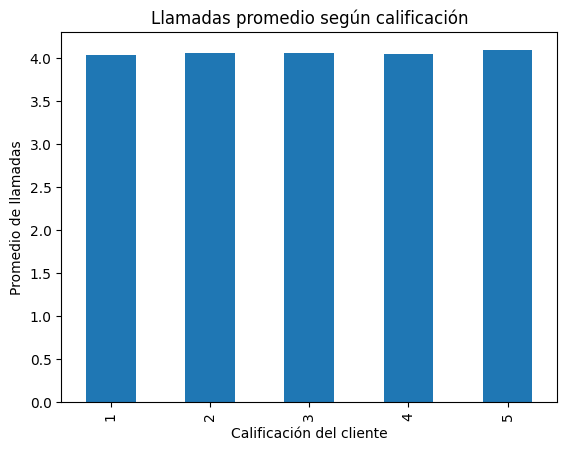

In [ ]:
# 3. KPIs de Experiencia y Fidelización del Cliente

# 3.1 Índice de satisfacción del cliente CSAT promedio
csat_promedio = data['Customer_rating'].mean()
print('3.1 CSAT promedio')
print('CSAT promedio:', round(csat_promedio, 2), 'de 5')

# CSAT segmentado por género y por bloque de bodega
csat_genero = data.groupby('Gender')['Customer_rating'].mean()
csat_bodega = data.groupby('Warehouse_block')['Customer_rating'].mean()

print('\nCSAT por género')
print(csat_genero)
print('\nCSAT por bloque de bodega')
print(csat_bodega)

# 3.2 Tasa de retención / clientes recurrentes
# La guía indica: clientes nuevos = 0 o 1 compras previas; fidelizados = 2 o más.
clientes_nuevos = data[data['Prior_purchases'] <= 1]
clientes_recurrentes = data[data['Prior_purchases'] >= 2]

tasa_clientes_nuevos = (len(clientes_nuevos) / len(data)) * 100
tasa_clientes_recurrentes = (len(clientes_recurrentes) / len(data)) * 100

print('\n3.2 Tasa de retención / clientes recurrentes')
print('Clientes nuevos:', round(tasa_clientes_nuevos, 2), '%')
print('Clientes recurrentes:', round(tasa_clientes_recurrentes, 2), '%')

# 3.3 Carga de soporte por cliente
llamadas_promedio = data['Customer_care_calls'].mean()
print('\n3.3 Carga de soporte por cliente')
print('Promedio de llamadas al soporte:', round(llamadas_promedio, 2))

# Relación sencilla entre llamadas, costo y calificación
soporte_por_rating = data.groupby('Customer_rating')['Customer_care_calls'].mean()
print('\nLlamadas promedio según calificación del cliente')
print(soporte_por_rating)

# Gráfico simple
soporte_por_rating.plot(kind='bar', title='Llamadas promedio según calificación', xlabel='Calificación del cliente', ylabel='Promedio de llamadas')

#### Interpretación de los KPIs de Experiencia y Fidelización

El CSAT promedio permite saber cómo califican los clientes el servicio recibido. Si el valor está cerca de 3, la satisfacción es regular; si se acerca a 5, la experiencia es buena. Al segmentarlo por género o bloque de bodega se pueden encontrar diferencias en la atención o en la operación.

La tasa de clientes recurrentes muestra qué parte de la base ya ha comprado varias veces. Si la mayoría tiene 2 o más compras previas, se puede decir que existe una buena fidelización.

La carga de soporte indica cuántas llamadas realiza en promedio cada cliente. Si los clientes con menor calificación hacen más llamadas, eso puede indicar problemas en la experiencia de compra o en la entrega.